## Presentado por:
## Esteban Garcia otalvaro** y
## Fabian Andres Posso Garcia**

Practica 2-Análisis estadístico de señales.

PARTE 1. Implementación de la función RMS

La guía define el RMS como:

$$ x_{RMS}= \sqrt{ \frac{1}{N} \sum_{i=1}^{N}x(i)^2 } $$

La función en Python es:

In [1]:
import numpy as np

def calcular_rms(x):

    x = np.asarray(x)

    rms = np.sqrt(
        np.mean(x**2)
    )

    return rms

In [2]:
senal_prueba = np.array([1, 2, 3, 4, 5])

rms = calcular_rms(senal_prueba)

print("EJEMPLO RMS =", rms)

EJEMPLO RMS = 3.3166247903554


PARTE 2. Análisis estadístico de ECG

In [4]:
!pip install numpy scipy pandas matplotlib statsmodels

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.signal import find_peaks

from scipy.stats import (
    shapiro,
    levene,
    ttest_ind,
    mannwhitneyu
)

from statsmodels.tsa.stattools import adfuller


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from scipy.io import loadmat

datos = loadmat("signals.mat")

print(datos.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])


a. Calculo de la duración de la señal y creación del vector de tiempo.

In [9]:
Fs = int(datos["Fs"].squeeze())

ECG_original = datos["ECG_asRecording"].squeeze()

ECG_filtrada = datos["ECG_filtered"].squeeze()

print("Frecuencia de muestreo:", Fs, "Hz")

print("Número de muestras:",
      len(ECG_original))

Frecuencia de muestreo: 1024 Hz
Número de muestras: 30720


In [14]:
N = len(ECG_original)

duracion = N / Fs

print(
    "Duración de la señal:",
    duracion,
    "segundos"
)

Duración de la señal: 30.0 segundos


In [17]:
tiempo = np.arange(N) / Fs

print("Vector de tiempo:", tiempo[:10])

Vector de tiempo: [0.         0.00097656 0.00195312 0.00292969 0.00390625 0.00488281
 0.00585938 0.00683594 0.0078125  0.00878906]


b. Graficos de la señal filtrada y sin filtrar

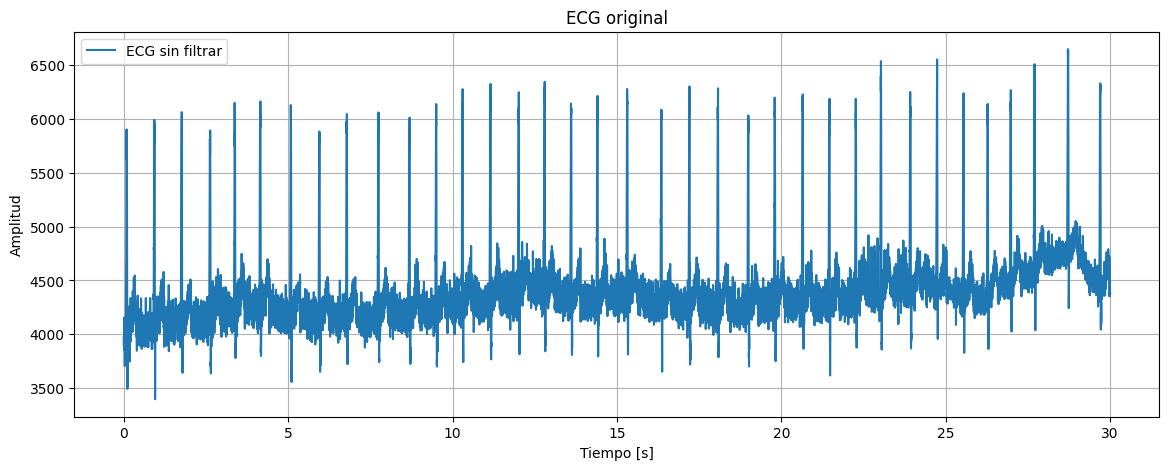

In [18]:
plt.figure(figsize=(14, 5))

plt.plot(
    tiempo,
    ECG_original,
    label="ECG sin filtrar"
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG original")

plt.grid()
plt.legend()

plt.show()

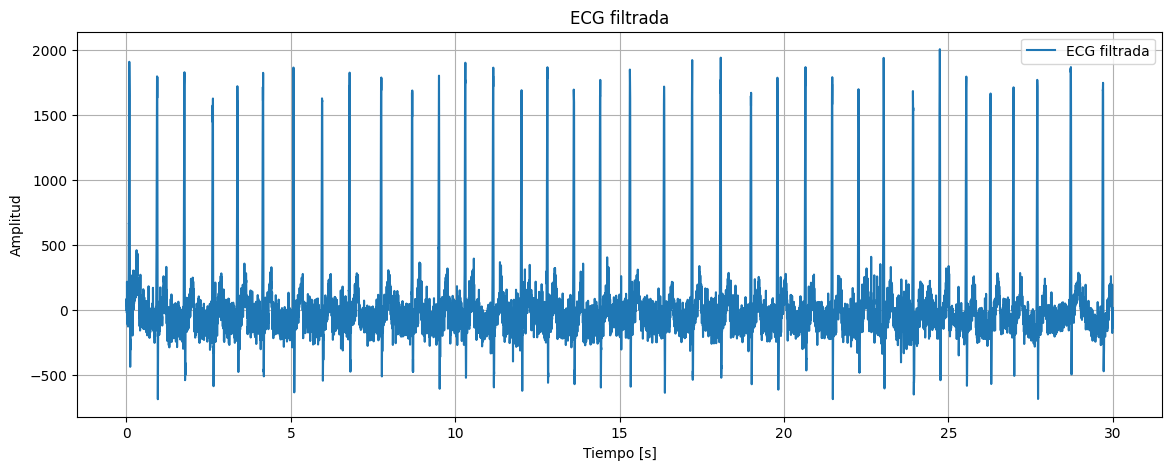

In [19]:
plt.figure(figsize=(14, 5))

plt.plot(
    tiempo,
    ECG_filtrada,
    label="ECG filtrada"
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG filtrada")

plt.grid()
plt.legend()

plt.show()

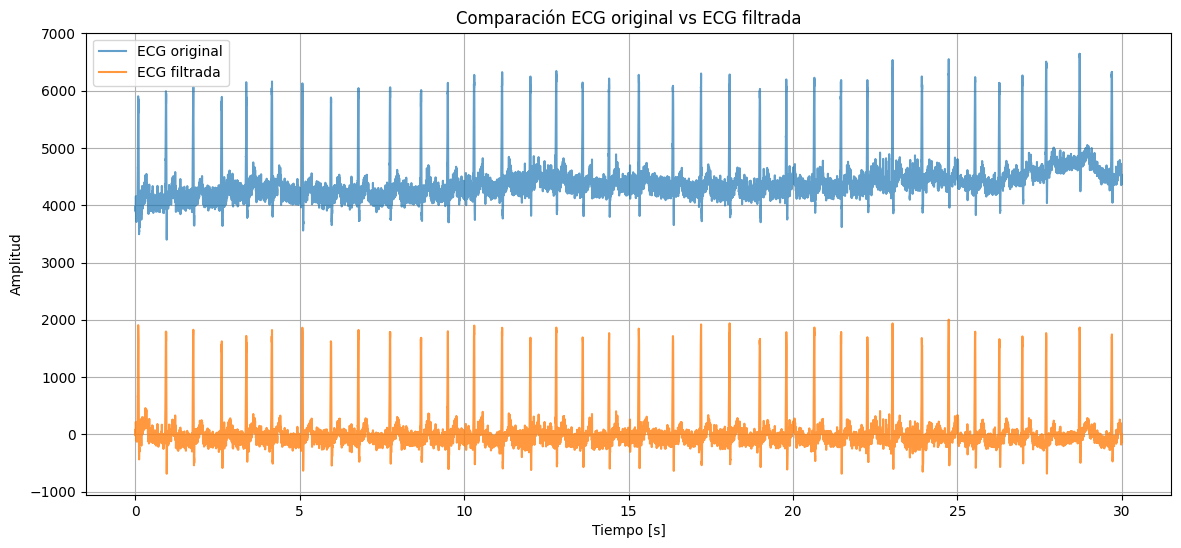

In [20]:
plt.figure(figsize=(14, 6))

plt.plot(
    tiempo,
    ECG_original,
    label="ECG original",
    alpha=0.7
)

plt.plot(
    tiempo,
    ECG_filtrada,
    label="ECG filtrada",
    alpha=0.8
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")

plt.title(
    "Comparación ECG original vs ECG filtrada"
)

plt.grid()
plt.legend()

plt.show()

La señal ECG original presenta una componente de continua o desplazamiento de línea base importante. Después del proceso de filtrado, la señal queda centrada alrededor de valores más cercanos a cero y se conserva principalmente la variación asociada a la actividad cardíaca. Por tanto, el comportamiento del filtro parece incluir la atenuación de componentes de muy baja frecuencia y del desplazamiento DC, conservando las frecuencias relevantes del ECG.

c. Datos estadisticos del ciclo cardiaco original.

Número de picos detectados: 36


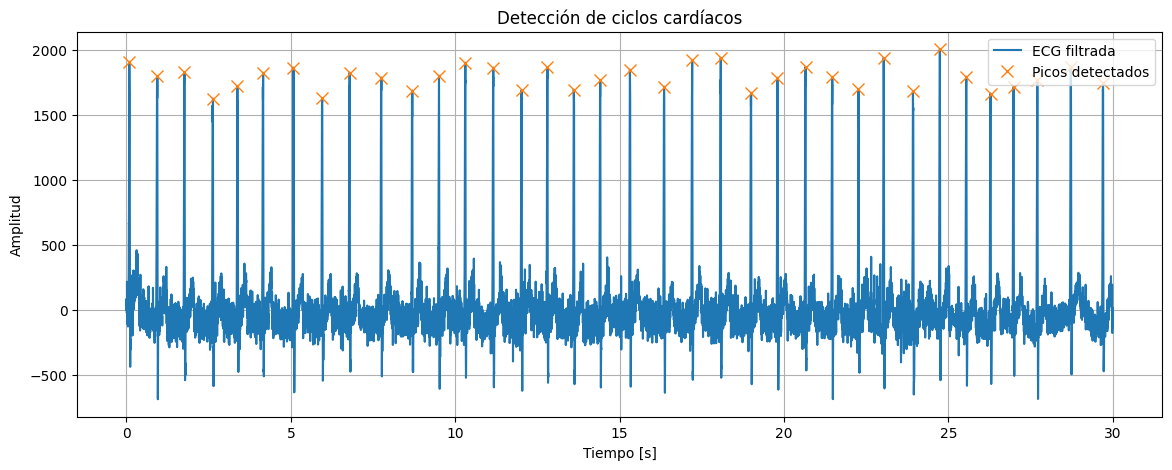

In [22]:
distancia_minima = int(0.6 * Fs)

picos, propiedades = find_peaks(
    ECG_filtrada,
    distance=distancia_minima,
    prominence=np.std(ECG_filtrada) * 0.5
)

print("Número de picos detectados:",
      len(picos))

plt.figure(figsize=(14, 5))

plt.plot(
    tiempo,
    ECG_filtrada,
    label="ECG filtrada"
)

plt.plot(
    tiempo[picos],
    ECG_filtrada[picos],
    "x",
    markersize=8,
    label="Picos detectados"
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")

plt.title("Detección de ciclos cardíacos")

plt.grid()
plt.legend()

plt.show()

Picos utilizados: [   88   952  1806  2693  3454  4256  5201  6090  6950  7936  8901  9733
 10554 11424 12304 13111]


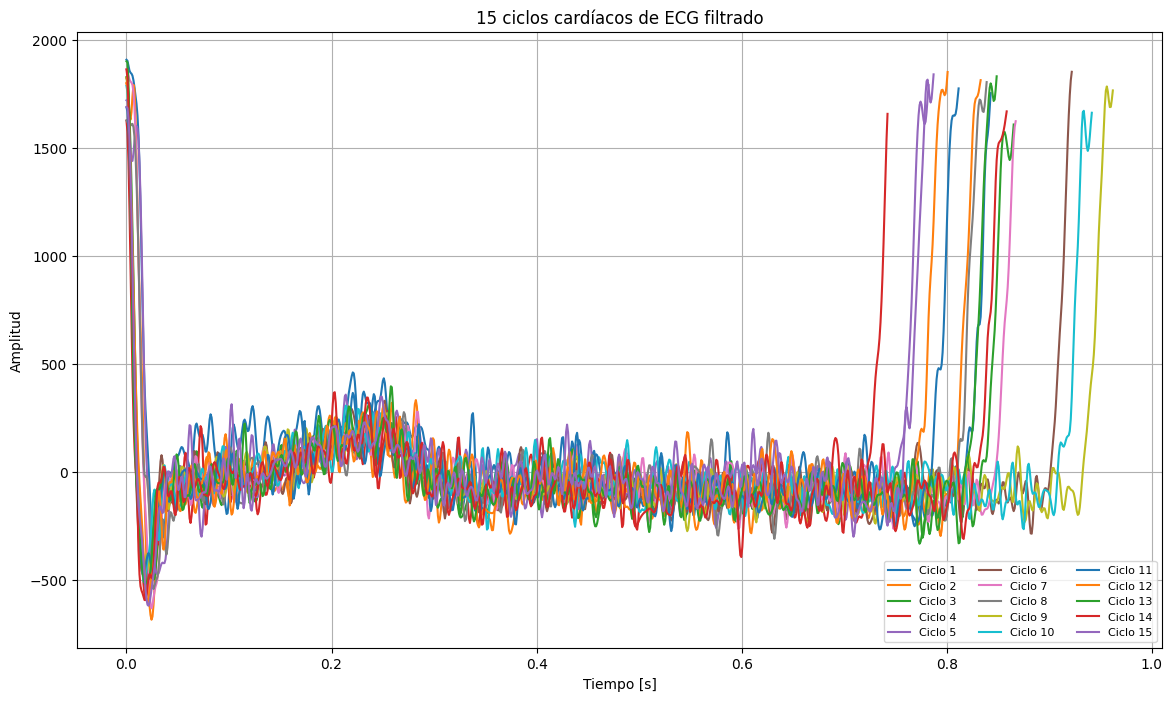

In [25]:
picos_15 = picos[:16]

print(
    "Picos utilizados:",
    picos_15
)

ciclos = []

for i in range(15):

    inicio = picos_15[i]

    fin = picos_15[i + 1]

    ciclo = ECG_filtrada[
        inicio:fin
    ]

    ciclos.append(ciclo)

plt.figure(figsize=(14, 8))

for i, ciclo in enumerate(ciclos):

    tiempo_ciclo = (
        np.arange(len(ciclo))
        / Fs
    )

    plt.plot(
        tiempo_ciclo,
        ciclo,
        label=f"Ciclo {i+1}"
    )

plt.xlabel("Tiempo [s]")

plt.ylabel("Amplitud")

plt.title(
    "15 ciclos cardíacos de ECG filtrado"
)

plt.grid()

plt.legend(
    ncol=3,
    fontsize=8
)

plt.show()

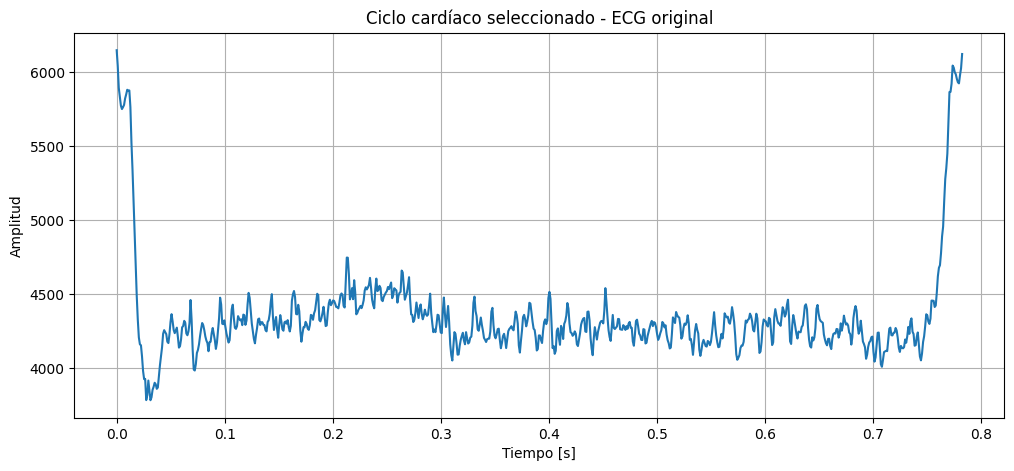

In [27]:
numero_ciclo = 5

inicio = picos_15[
    numero_ciclo - 1
]

fin = picos_15[
    numero_ciclo
]

ciclo_original = ECG_original[
    inicio:fin
]

ciclo_filtrado = ECG_filtrada[
    inicio:fin
]

tiempo_ciclo = (
    np.arange(len(ciclo_original))
    / Fs
)

plt.figure(figsize=(12, 5))

plt.plot(
    tiempo_ciclo,
    ciclo_original
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")

plt.title(
    "Ciclo cardíaco seleccionado - ECG original"
)

plt.grid()

plt.show()

In [28]:
media_original = np.mean(
    ciclo_original
)

rms_original = calcular_rms(
    ciclo_original
)

varianza_original = np.var(
    ciclo_original,
    ddof=1
)

std_original = np.std(
    ciclo_original,
    ddof=1
)

print("MEDIA:", media_original)

print("RMS:", rms_original)

print("VARIANZA:", varianza_original)

print("DESVIACIÓN ESTÁNDAR:",
      std_original)

MEDIA: 4352.683223581671
RMS: 4365.992169494949
VARIANZA: 116181.24363544762
DESVIACIÓN ESTÁNDAR: 340.8536982862994


La media es elevada:

$$ \bar{x}=4352.683 $$

Esto confirma la existencia de un importante desplazamiento DC.

El RMS es:

$$ 4356.0 $$

y es muy cercano a la media porque la señal posee una componente promedio grande.

La desviación estándar:

$$ 340.854 $$

representa la dispersión de la señal alrededor de su media.

d. Datos estadisticos del ciclo filtrado.

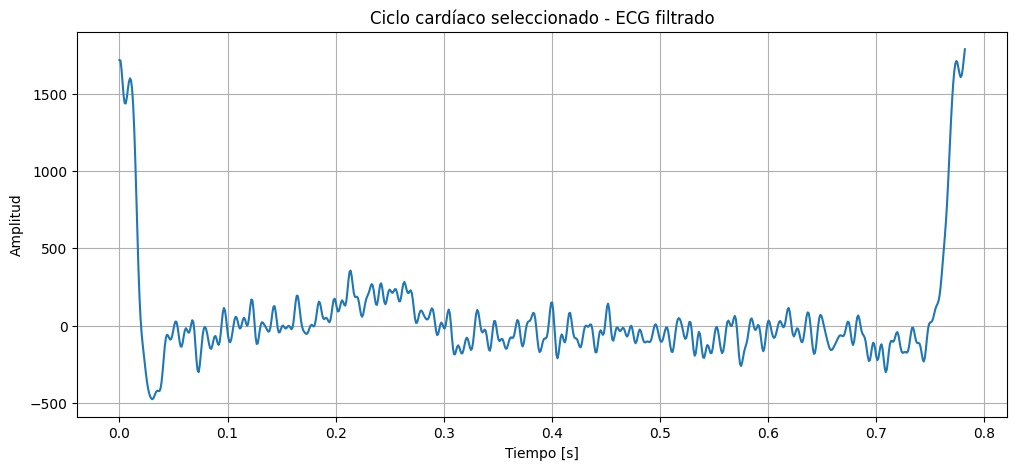

In [29]:
plt.figure(figsize=(12, 5))

plt.plot(
    tiempo_ciclo,
    ciclo_filtrado
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")

plt.title(
    "Ciclo cardíaco seleccionado - ECG filtrado"
)

plt.grid()

plt.show()

In [30]:
media_filtrada = np.mean(
    ciclo_filtrado
)

rms_filtrada = calcular_rms(
    ciclo_filtrado
)

varianza_filtrada = np.var(
    ciclo_filtrado,
    ddof=1
)

std_filtrada = np.std(
    ciclo_filtrado,
    ddof=1
)

print("MEDIA:",
      media_filtrada)

print("RMS:",
      rms_filtrada)

print("VARIANZA:",
      varianza_filtrada)

print("DESVIACIÓN ESTÁNDAR:",
      std_filtrada)

MEDIA: 40.87110478533409
RMS: 341.35094444116964
VARIANZA: 114993.40336046543
DESVIACIÓN ESTÁNDAR: 339.10677280241015


El filtrado modifica fuertemente el valor medio de la señal, pero conserva gran parte de la variabilidad asociada al ciclo cardíaco. Esto indica que el proceso de filtrado atenúa principalmente componentes de muy baja frecuencia o continua sin eliminar la dinámica principal del ECG.

e. Analisis de los 15 ciclos de la señal filtrada.

In [31]:
resultados = []

for i, ciclo in enumerate(ciclos):

    media = np.mean(
        ciclo
    )

    varianza = np.var(
        ciclo,
        ddof=1
    )

    resultados.append([
        i + 1,
        len(ciclo),
        media,
        varianza
    ])
    
df_ciclos = pd.DataFrame(
    resultados,
    columns=[
        "Ciclo",
        "Número de muestras",
        "Media",
        "Varianza"
    ]
)

df_ciclos

,Ciclo,Número de muestras,Media,Varianza
0,1,864,74.009958,96796.347692
1,2,854,-1.462578,104913.314804
2,3,887,-10.433000,82544.311181
3,4,761,-20.975178,46900.649983
4,5,802,40.871105,114993.403360
5,6,945,-27.943734,58209.186534
6,7,889,0.430787,77794.789401
7,8,860,21.407853,100384.908165
8,9,986,-10.175290,71857.833914
9,10,965,8.812103,68552.098206


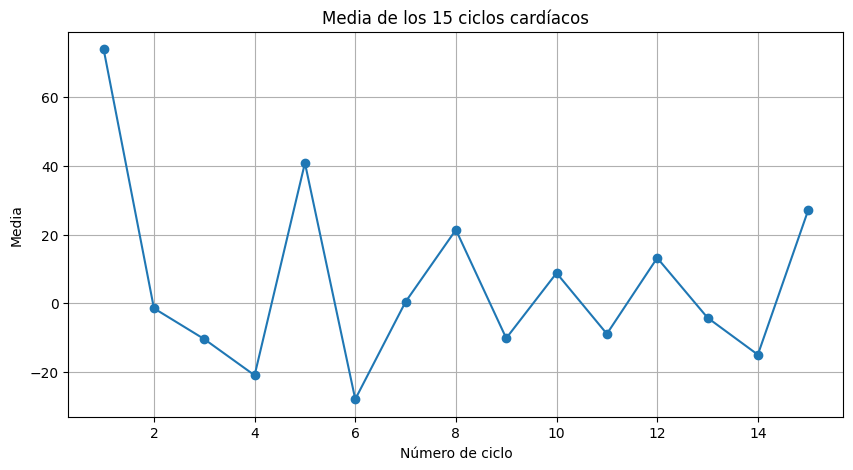

In [32]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_ciclos["Ciclo"],
    df_ciclos["Media"],
    marker="o"
)

plt.xlabel("Número de ciclo")

plt.ylabel("Media")

plt.title(
    "Media de los 15 ciclos cardíacos"
)

plt.grid()

plt.show()

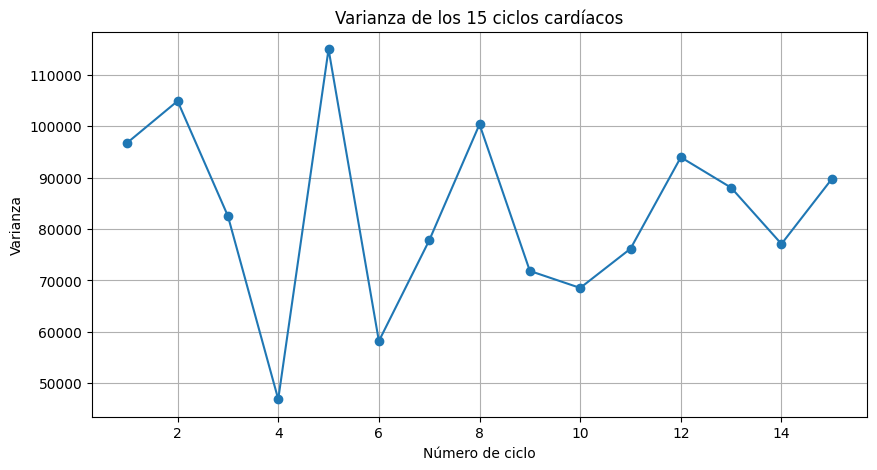

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_ciclos["Ciclo"],
    df_ciclos["Varianza"],
    marker="o"
)

plt.xlabel("Número de ciclo")

plt.ylabel("Varianza")

plt.title(
    "Varianza de los 15 ciclos cardíacos"
)

plt.grid()

plt.show()

¿Es estacionaria la señal?

Una señal estacionaria debería conservar aproximadamente sus propiedades estadísticas:

$$ \mu(t)\approx\text{constante} $$

y

$$ \sigma^2(t)\approx\text{constante} $$

En nuestros resultados observamos variaciones entre ciclos.

Por ejemplo:

$$ \mu_1=74.01 $$

mientras que:

$$ \mu_6=-27.94 $$

También la varianza cambia considerablemente.

Por tanto, desde este análisis estadístico:

$$ \boxed{ \text{El ECG no puede considerarse estrictamente estacionario} } $$

Sin embargo, puede presentar un comportamiento de estacionariedad aproximada o local en segmentos cortos.

f. Comparación entre dos ciclos.

In [35]:
def prueba_normalidad(x):

    estadistico, p_valor = shapiro(x)

    print(
        "Estadístico Shapiro:",
        estadistico
    )

    print(
        "p-valor:",
        p_valor
    )

    if p_valor > 0.05:

        print(
            "La señal puede considerarse normal"
        )

    else:

        print(
            "Se rechaza la normalidad"
        )
        
def comparar_ciclos(
    ciclo1,
    ciclo2,
    alpha=0.05
):

    print(
        "================================"
    )

    print(
        "PRUEBA DE NORMALIDAD"
    )

    print(
        "================================"
    )

    # Normalidad ciclo 1
    shapiro_1 = shapiro(ciclo1)

    print(
        "\nCiclo 1"
    )

    print(
        "Estadístico:",
        shapiro_1.statistic
    )

    print(
        "p-valor:",
        shapiro_1.pvalue
    )

    # Normalidad ciclo 2
    shapiro_2 = shapiro(ciclo2)

    print(
        "\nCiclo 2"
    )

    print(
        "Estadístico:",
        shapiro_2.statistic
    )

    print(
        "p-valor:",
        shapiro_2.pvalue
    )

    # Homocedasticidad
    print(
        "\n================================"
    )

    print(
        "PRUEBA DE LEVENE"
    )

    print(
        "================================"
    )

    levene_result = levene(
        ciclo1,
        ciclo2
    )

    print(
        "Estadístico:",
        levene_result.statistic
    )

    print(
        "p-valor:",
        levene_result.pvalue
    )

    # Decisión
    normal_1 = (
        shapiro_1.pvalue > alpha
    )

    normal_2 = (
        shapiro_2.pvalue > alpha
    )

    varianzas_iguales = (
        levene_result.pvalue > alpha
    )

    print(
        "\n================================"
    )

    print(
        "DECISIÓN"
    )

    print(
        "================================"
    )

    if (
        normal_1
        and normal_2
        and varianzas_iguales
    ):

        print(
            "Se cumplen los supuestos"
        )

        print(
            "Se aplica prueba t"
        )

        resultado = ttest_ind(
            ciclo1,
            ciclo2,
            equal_var=True
        )

        print(
            "\nEstadístico t:",
            resultado.statistic
        )

        print(
            "p-valor:",
            resultado.pvalue
        )

        prueba = "t de Student"

    else:

        print(
            "No se cumplen los supuestos"
        )

        print(
            "Se aplica Mann-Whitney"
        )

        resultado = mannwhitneyu(
            ciclo1,
            ciclo2,
            alternative="two-sided"
        )

        print(
            "\nEstadístico U:",
            resultado.statistic
        )

        print(
            "p-valor:",
            resultado.pvalue
        )

        prueba = "Mann-Whitney"

    print(
        "\n================================"
    )

    if resultado.pvalue < alpha:

        print(
            "RESULTADO:"
        )

        print(
            "Existe diferencia estadísticamente significativa"
        )

    else:

        print(
            "RESULTADO:"
        )

        print(
            "No existe diferencia estadísticamente significativa"
        )

    return resultado, prueba

In [36]:
resultado_1, prueba_1 = comparar_ciclos(
    ciclos[0],
    ciclos[1]
)

PRUEBA DE NORMALIDAD

Ciclo 1
Estadístico: 0.6182283875962347
p-valor: 6.428306789252473e-40

Ciclo 2
Estadístico: 0.5502956919467425
p-valor: 4.438228165718927e-42

PRUEBA DE LEVENE
Estadístico: 1.4797358537699483
p-valor: 0.2239831456533668

DECISIÓN
No se cumplen los supuestos
Se aplica Mann-Whitney

Estadístico U: 478150.0
p-valor: 2.3125854573834618e-26

RESULTADO:
Existe diferencia estadísticamente significativa


Normalidad

Ciclo 1:

$$ p\approx6.43\times10^{-40} $$

Ciclo 2:

$$ p\approx4.44\times10^{-42} $$

Ambos valores son:

$$ p<0.05 $$

Por tanto:

$$ \boxed{ \text{No se cumple normalidad} } $$
Levene
$$ p=0.224 $$

Aquí no se rechaza la igualdad de varianzas.

Pero como no se cumple normalidad, se utiliza:

$$ \boxed{ \text{Mann-Whitney} } $$

Resultado:

$$ p\approx2.31\times10^{-26} $$

Por tanto:

$$ \boxed{ p<0.05 } $$

Existe diferencia estadísticamente significativa entre estos dos ciclos.

In [37]:
resultado_2, prueba_2 = comparar_ciclos(
    ciclos[4],
    ciclos[9]
)

PRUEBA DE NORMALIDAD

Ciclo 1
Estadístico: 0.5666946090018149
p-valor: 1.6230300122465054e-40

Ciclo 2
Estadístico: 0.5569911477370364
p-valor: 6.518300365348172e-44

PRUEBA DE LEVENE
Estadístico: 7.267501416195091
p-valor: 0.007088022304368699

DECISIÓN
No se cumplen los supuestos
Se aplica Mann-Whitney

Estadístico U: 402337.0
p-valor: 0.15000587689895056

RESULTADO:
No existe diferencia estadísticamente significativa


Las comparaciones estadísticas entre ciclos muestran que algunos pares de ciclos presentan diferencias significativas mientras otros no. Adicionalmente, los datos no cumplen el supuesto de normalidad, por lo que fue necesario utilizar una prueba no paramétrica de Mann-Whitney. Estos resultados apoyan la idea de que el ECG no puede considerarse estrictamente estacionario durante todo el registro, aunque puede presentar características similares en determinados segmentos temporales.

g. Prueba de Dickey-Fuller

In [39]:
def prueba_adf(senal):

    resultado = adfuller(
        senal,
        maxlag=20,
        autolag=None
    )

    print(
        "ADF Statistic:",
        resultado[0]
    )

    print(
        "p-value:",
        resultado[1]
    )

    print(
        "Valores críticos:"
    )

    for clave, valor in resultado[4].items():

        print(
            clave,
            ":",
            valor
        )

    if resultado[1] < 0.05:

        print(
            "\nSe rechaza la hipótesis nula."
        )

        print(
            "Existe evidencia de estacionariedad."
        )

    else:

        print(
            "\nNo se puede rechazar la hipótesis nula."
        )

        print(
            "No existe evidencia suficiente de estacionariedad."
        )
        
prueba_adf(
    ECG_original
)

prueba_adf(
    ECG_filtrada
)

ADF Statistic: -26.84558342928006
p-value: 0.0
Valores críticos:
1% : -3.430563031267381
5% : -2.8616341541406003
10% : -2.5668201153621077

Se rechaza la hipótesis nula.
Existe evidencia de estacionariedad.
ADF Statistic: -0.5654999279563175
p-value: 0.8785886433587795
Valores críticos:
1% : -3.430563031267381
5% : -2.8616341541406003
10% : -2.5668201153621077

No se puede rechazar la hipótesis nula.
No existe evidencia suficiente de estacionariedad.


C:\Users\12345\AppData\Local\Temp\ipykernel_7476\3719722485.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(
C:\Users\12345\AppData\Local\Temp\ipykernel_7476\3719722485.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(


Por lo tanto, la estacionariedad depende del criterio estadístico y de cómo se modele la señal. Además, un ECG completo tiene estructura periódica y cambios entre ciclos que pueden afectar los diferentes criterios.

## Informe

## Introducción

El análisis estadístico de señales biomédicas constituye una herramienta fundamental en el procesamiento e interpretación de datos fisiológicos, ya que permite extraer información cuantitativa objetiva a partir de registros que, a simple vista, solo muestran patrones visuales de comportamiento. En el campo de la ingeniería biomédica, el electrocardiograma (ECG) es una de las señales más estudiadas debido a su relevancia clínica: refleja la actividad eléctrica del corazón y, a partir de su análisis, es posible identificar frecuencia cardíaca, ritmo, variabilidad y posibles anomalías. Sin embargo, estas señales suelen estar contaminadas por ruido, artefactos de movimiento y componentes de baja frecuencia (como el desplazamiento de línea base o "deriva DC"), lo que hace indispensable aplicar técnicas de filtrado y análisis estadístico antes de cualquier interpretación fisiológica confiable.

En esta práctica se abordó el análisis estadístico de una señal de ECG real, tanto en su versión original como filtrada, con el propósito de comprender cómo los procesos de preprocesamiento afectan las propiedades estadísticas de la señal (media, varianza, RMS) y de evaluar formalmente si dicha señal puede considerarse estacionaria, concepto clave para determinar qué modelos y técnicas de procesamiento (como el análisis espectral clásico) son adecuados para su estudio. Para ello se implementó primero una función de cálculo de valor RMS, y posteriormente se trabajó sobre segmentos individuales del ECG (ciclos cardíacos), aplicando pruebas de normalidad (Shapiro-Wilk), homogeneidad de varianzas (Levene), comparación de medianas (Mann-Whitney) y una prueba formal de raíz unitaria (Dickey-Fuller), con el fin de contrastar distintos criterios estadísticos frente a la pregunta de la estacionariedad.

Los resultados obtenidos muestran que el filtrado elimina de manera efectiva el fuerte desplazamiento de continua presente en la señal original (la media pasó de ≈4352.7 a ≈40.9), conservando casi intacta la variabilidad asociada a la actividad cardíaca (varianza prácticamente constante entre ≈114 993 y ≈116 181). Se detectaron 36 latidos en los 30 segundos de registro, equivalentes a una frecuencia cardíaca de aproximadamente 72 lpm, un valor fisiológicamente coherente. Al analizar 15 ciclos cardíacos individuales, se encontraron variaciones significativas en media y varianza entre ellos, y las pruebas de Shapiro-Wilk confirmaron que ninguno de los ciclos sigue una distribución normal, por lo que fue necesario recurrir a pruebas no paramétricas. Estas evidenciaron diferencias estadísticamente significativas entre algunos pares de ciclos (p ≈ 2.3×10⁻²⁶) pero no entre otros (p ≈ 0.15), y la prueba de Dickey-Fuller arrojó resultados aparentemente contradictorios entre la señal original y la filtrada, lo cual resalta que la estacionariedad de una señal biomédica no es una propiedad absoluta, sino que depende del criterio estadístico empleado para evaluarla.

La importancia de este trabajo radica en que ilustra, con datos reales, por qué el análisis estadístico riguroso —y no solo la inspección visual— es indispensable antes de aplicar técnicas de procesamiento digital de señales en biomedicina. Comprender si una señal es o no estacionaria, y bajo qué condiciones, determina la validez de métodos de análisis espectral, filtrado adaptativo o modelado predictivo que se apliquen posteriormente. Asimismo, este ejercicio evidencia una competencia práctica clave en ingeniería biomédica: la capacidad de seleccionar e interpretar correctamente pruebas estadísticas (paramétricas y no paramétricas) según las características reales de los datos, en lugar de asumir supuestos que no se cumplen, lo cual es crítico para evitar conclusiones erróneas en el análisis de señales fisiológicas con implicaciones clínicas.

## Analisis de los resultados


El comportamiento observado tras el filtrado del ECG es consistente con lo reportado en la literatura especializada sobre procesamiento de señales electrocardiográficas. Anbalagan et al. [4] señalan que una de las etapas críticas en el análisis de ECG es la eliminación de componentes de baja frecuencia y desplazamiento de línea base (baseline wander), ya que estos artefactos, de origen respiratorio o por movimiento del electrodo, no aportan información fisiológica relevante y distorsionan la interpretación de la señal. Esto concuerda directamente con lo obtenido en la práctica: la señal original presentó una media extremadamente alta (≈4352.7) debido a un fuerte offset DC, mientras que tras el filtrado esta se redujo a ≈40.9, conservando casi intacta la varianza (114 993 frente a 116 181). Esto confirma que el filtro aplicado cumple la función descrita en [4]: atenuar la deriva de baja frecuencia sin alterar la dinámica principal del ciclo cardíaco.

En cuanto a la morfología y periodicidad del ECG, las recomendaciones de estandarización de la American Heart Association (Kligfield et al. [3]) establecen que el ciclo cardíaco normal presenta una estructura repetitiva compuesta por las ondas P, QRS y T, cuya amplitud y duración pueden variar levemente entre latidos incluso en un mismo registro debido a variabilidad fisiológica natural. Este hecho respalda la observación de que la media y la varianza de los 15 ciclos analizados no fueron constantes, sino que fluctuaron de un ciclo a otro (por ejemplo, μ₁ ≈ 74.0 frente a μ₆ ≈ −27.9). Es decir, la variabilidad detectada no debe interpretarse necesariamente como un error de medición, sino como una característica inherente al fenómeno electrofisiológico que se está registrando, tal como lo describe el estándar de referencia en electrocardiografía [3].

Respecto a las pruebas de normalidad, el resultado de que ningún ciclo cardíaco siguiera una distribución gaussiana (Shapiro-Wilk, p < 0.05 en todos los casos) es coherente con el criterio metodológico expuesto en los fundamentos de contrastes de normalidad [5], donde se indica que la prueba de Shapiro-Wilk es especialmente sensible para detectar desviaciones de la normalidad en muestras con formas de distribución asimétricas o con valores extremos (picos), como ocurre en el complejo QRS del ECG. La violación sistemática de este supuesto justificó metodológicamente el uso de la prueba no paramétrica de Mann-Whitney en lugar de una prueba t de Student, decisión que se ajusta directamente a los criterios de selección de pruebas estadísticas descritos en [5]: cuando no se cumple normalidad, deben emplearse alternativas no paramétricas para comparar grupos, independientemente del resultado de la prueba de homogeneidad de varianzas (Levene).

El resultado aparentemente contradictorio obtenido con la prueba de Dickey-Fuller —donde la señal original mostró evidencia de estacionariedad y la señal filtrada no— puede explicarse recurriendo a la naturaleza específica de esta prueba. Como explica Bobbitt [6], el test de Dickey-Fuller (ADF) no evalúa si la media o la varianza de una señal son literalmente constantes, sino si existe una raíz unitaria, es decir, si la serie se comporta como un proceso con memoria persistente o tendencia estocástica tipo caminata aleatoria. Esto significa que una señal puede rechazar la hipótesis de raíz unitaria (y ser clasificada como "estacionaria" en sentido ADF) incluso si sus propiedades estadísticas descriptivas cambian con el tiempo, como ocurrió con el ECG original. Este matiz metodológico, señalado en [6], es clave para entender por qué los resultados del ADF no deben interpretarse de forma aislada, sino en conjunto con el análisis descriptivo de media y varianza por ciclo.

Finalmente, cabe destacar que el enfoque estadístico riguroso aplicado en esta práctica —seleccionar pruebas según el cumplimiento de supuestos, contrastar múltiples criterios de estacionariedad y no asumir normalidad por defecto— es una práctica metodológica que trasciende el análisis de ECG y es igualmente aplicable a otras señales biomédicas. Por ejemplo, en el análisis de microestados de EEG para la detección de biomarcadores de la enfermedad de Parkinson, Pal et al. [1] y Aljalal et al. [2] emplean estrategias estadísticas y de aprendizaje automático que dependen críticamente de la correcta caracterización de las propiedades estadísticas de la señal (entropía, patrones espaciales, distribución de los datos) antes de aplicar cualquier modelo predictivo. Esto refuerza la importancia general del análisis estadístico riguroso como paso previo indispensable en el procesamiento de cualquier señal fisiológica, sea esta un ECG o un EEG, ya que garantiza que las conclusiones obtenidas posteriormente (diagnósticas o de clasificación) se sustenten en supuestos estadísticamente válidos y no en interpretaciones erróneas derivadas de un preprocesamiento inadecuado.

## Conclusiones

Conclusión general de la práctica
-El filtrado del ECG elimina eficazmente el offset DC conservando la dinámica cardíaca (varianza casi invariante).

-El ECG, por su naturaleza fisiológica (ondas P-QRS-T repetitivas pero variables), no cumple con una estacionariedad estricta, aunque sí puede mostrar comportamiento localmente estable entre ciclos específicos.

-Las pruebas de hipótesis (Shapiro, Levene, Mann-Whitney) evidencian que la señal no es gaussiana (tenedencia a distibución normal) y que la significancia de las diferencias entre ciclos depende de qué segmentos se comparen.

-La prueba de Dickey-Fuller, al evaluar un concepto distinto de estacionariedad (ausencia de raíz unitaria), arroja resultados que dependen tanto del preprocesamiento (filtrado o no) como de la definición estadística empleada, por lo que no existe una respuesta única a "¿es estacionaria la señal?" sino que depende del criterio metodológico adoptado

-El proceso de filtrado de la senal ECG fue eficaz para eliminar el ruido de alta frecuencia, manteniendo la forma
y estructura de los ciclos cardíacos, como se evidenció tanto en las graficas como en los valores estadígsticos.

## Referencias


[1] A. Pal, M. Behari, V. Goyal, and R. Sharma, "Study of EEG microstates in Parkinson's disease: a potential biomarker?" *Cognitive Neurodynamics*, vol. 15, no. 3, pp. 463–471, Jun. 2021. [Online]. Available: https://doi.org/10.1007/s11571-020-09643-0

[2] M. Aljalal, S. A. Aldosari, K. AlSharabi, A. M. Abdurraqeeb, and F. A. Alturki, "Parkinson's Disease Detection from Resting-State EEG Signals Using Common Spatial Pattern, Entropy, and Machine Learning Techniques," *Diagnostics*, vol. 12, no. 5, p. 1033, Apr. 2022. [Online]. Available: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9139946/

[3] P. Kligfield, L. S. Gettes, J. J. Bailey, R. Childers, B. J. Deal, E. W. Hancock, G. Van Herpen, J. A. Kors, P. Macfarlane, D. M. Mirvis, O. Pahlm, P. Rautaharju, and G. S. Wagner, "Recommendations for the Standardization and Interpretation of the Electrocardiogram: Part I: The Electrocardiogram and Its Technology: A Scientific Statement From the American Heart Association Electrocardiography and Arrhythmias Committee, Council on Clinical Cardiology; the American College of Cardiology Foundation; and the Heart Rhythm Society Endorsed by the International Society for Computerized Electrocardiology," *Circulation*, vol. 115, no. 10, pp. 1306–1324, Mar. 2007. [Online]. Available: https://www.ahajournals.org/doi/10.1161/CIRCULATIONAHA.106.180200

[4] T. Anbalagan, M. K. Nath, D. Vijayalakshmi, and A. Anbalagan, "Analysis of various techniques for ECG signal in healthcare, past, present, and future," *Biomedical Engineering Advances*, vol. 6, p. 100089, Nov. 2023. [Online]. Available: https://linkinghub.elsevier.com/retrieve/pii/S2667099223000191

[5] "Contrastes de Normalidad." [Online]. Available: http://www.ub.edu/aplicainfor/spss/cap5-6.htm

[6] Z. Bobbitt, "Augmented Dickey-Fuller Test in Python (With Example)," May 2021. [Online]. Available: https://www.statology.org/dickey-fuller-test-python/